In [1]:
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette
from autoslo.workload_execution.trace import Trace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]
rpus = [4, 8, 16, 32]

slo_s = 180

records = []

for pct_heavy in pct_heavy_options:
    for mean_interarrival in mean_interarrival_options:
        for rpu in rpus:
            run_id = pu.RunLocator.get_run_ids(
                schema_name="ext_tpcds1000",
                workload_name=f"tpcds_99templates_{pct_heavy:02d}pctheavy_{mean_interarrival}meaninterarrivals",
                blueprint_name=f"single_{rpu}",
            )[-1]

            trace = Trace(run_id)
            latencies = trace.latencies_s
            costs = trace.costs

            records.append(
                {
                    "type": "baseline",
                    "pct_heavy": pct_heavy,
                    "mean_interarrival": mean_interarrival,
                    "rpu": rpu,
                    "run_id": run_id,
                    "slo_violation_rate": np.mean(
                        [1 if lat > slo_s else 0 for lat in latencies]
                    ),
                    "total_cost": sum(costs),
                    "slo_violation_time": np.sum(
                        [max(0, lat - slo_s) for lat in latencies]
                    ),
                }
            )

In [3]:
import yaml
import os

with open('selector_benchmarking_bookkeeping.yml', 'r') as f:
    bookkeeping = yaml.safe_load(f)

for run in bookkeeping['runs']:

    final_stats_path = os.path.join(    
        pu.get_data_path(), 
        'selector_runs',
        run['selector_run_id'],
        'final_stats.yml'
    )
    with open(final_stats_path, 'r') as f:
        final_stats = yaml.safe_load(f)


    records.append({
        "type": "ours_estimated",
        "pct_heavy": run['pct_heavy'],
        "mean_interarrival": run['mean_interarrival'],
        "rpu": "Ours",
        "run_id": None, 
        "slo_violation_rate": final_stats['final_slo_violation_rate'], 
        "total_cost": final_stats['final_total_cost'],
        "slo_violation_time": final_stats['final_slo_violation_amount']
    })

    selector_run_id = run['selector_run_id']
    run_ids = pu.RunLocator.get_run_ids(
                schema_name="ext_tpcds1000",
                workload_name=f"tpcds_99templates_{run['pct_heavy']:02d}pctheavy_{run['mean_interarrival']}meaninterarrivals",
                query_router_name=f"RSeqNum(selector_run_id='{selector_run_id}')",
            )
    if len(run_ids) == 0:
       
        continue

    run_id = run_ids[-1]
    trace = Trace(run_id)
    latencies = trace.latencies_s
    costs = trace.costs

    records.append({
        "type": "ours_actual",
        "pct_heavy": run['pct_heavy'],
        "mean_interarrival": run['mean_interarrival'],
        "rpu": "Ours",
        "run_id": run_id,
        "slo_violation_rate": np.mean([1 if lat > slo_s else 0 for lat in latencies]), 
        "total_cost": sum(costs),
        "slo_violation_time": np.sum([max(0, lat - slo_s) for lat in latencies])
    })  


In [43]:
run_id

'1770147922'

In [4]:
records_df = pd.DataFrame(records)
records_df

,type,pct_heavy,mean_interarrival,rpu,run_id,slo_violation_rate,total_cost,slo_violation_time
0,baseline,0,10,4,1763253188,0.517045,2.787917,134185.671693
1,baseline,0,10,8,1763253312,0.190341,2.913333,18770.816050
2,baseline,0,10,16,1763253072,0.090909,5.165000,7177.449079
3,baseline,0,10,32,1763928438,0.000000,10.900000,0.000000
4,baseline,0,30,4,1763249004,0.196850,1.407083,4775.596815
...,...,...,...,...,...,...,...,...
91,ours_actual,10,10,Ours,1770164022,0.266476,7.222917,123333.923050
92,ours_estimated,25,10,Ours,None,0.005764,4.563750,24.972336
93,ours_actual,25,10,Ours,1770171686,0.325648,9.632083,135671.915247
94,ours_estimated,50,10,Ours,None,0.647761,5.343333,275754.906250


In [45]:
records_df[records_df['pct_heavy'
                      ] == 00][records_df['mean_interarrival'] == 120]

/tmp/ipykernel_1296093/2157930476.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  records_df[records_df['pct_heavy'


,type,pct_heavy,mean_interarrival,rpu,run_id,slo_violation_rate,total_cost,slo_violation_time
12,baseline,0,120,4,1763240500,0.029412,0.755833,115.224193
13,baseline,0,120,8,1763240707,0.000000,1.402500,0.000000
14,baseline,0,120,16,1763240506,0.000000,2.865000,0.000000
15,baseline,0,120,32,1763915879,0.000000,5.646667,0.000000
64,ours_estimated,0,120,Ours,None,0.000000,0.852083,0.000000
65,ours_actual,0,120,Ours,1770061504,0.117647,1.292917,848.326282


In [5]:
# Plot a 4X4 grid of chunks. In each subplot, have a scatterplot where the
# x-axis is the total cost and the y-axis is the SLO violation rate. Have each
# value of RPU be a different color.

# Make all the fonts 14 pt
plt.rcParams.update({"font.size": 20})



colors = {
    4: Palette.light_yellow,
    8: Palette.light_orange,
    16: Palette.light_red,
    32: Palette.dark_orange,
    "ours_seqnum": Palette.light_blue,
    "ours_model": Palette.light_green,
}

def plot_one_panel(ax, pct_heavy, mean_interarrival, plot_time=False):
    subset = records_df[
        (records_df["pct_heavy"] == pct_heavy)
        & (records_df["mean_interarrival"] == mean_interarrival)
    ]

    xcolname = "slo_violation_rate" if not plot_time else "slo_violation_time"

    for rpu in rpus:
        rpu_subset = subset[subset["rpu"] == rpu]
        ax.scatter(
            rpu_subset[xcolname],
            rpu_subset["total_cost"],
            label=f"All on {rpu} RPU",
            s=300,
            color=colors[rpu],
        )
   


    # Plot our method
    ours_subset = subset[subset["type"] == "ours_estimated"]
    if len(ours_subset) > 0:
        ax.scatter(
            ours_subset[xcolname],
            ours_subset["total_cost"],
            label="Ours (Estimated)",
            s=250,
            edgecolors=colors["ours_seqnum"],
            marker="s",
            facecolors='none',
        )

     # Plot our method
    ours_subset = subset[subset["type"] == "ours_actual"]
    if len(ours_subset) > 0:
        ax.scatter(
            ours_subset[xcolname],
            ours_subset["total_cost"],
            label="Ours (Exact)",
            s=300,
            color=colors["ours_seqnum"],
            marker="*",
        )
    
    ax.set_title(
        f"{pct_heavy}% Heavy, Mean T={mean_interarrival}s"
    )



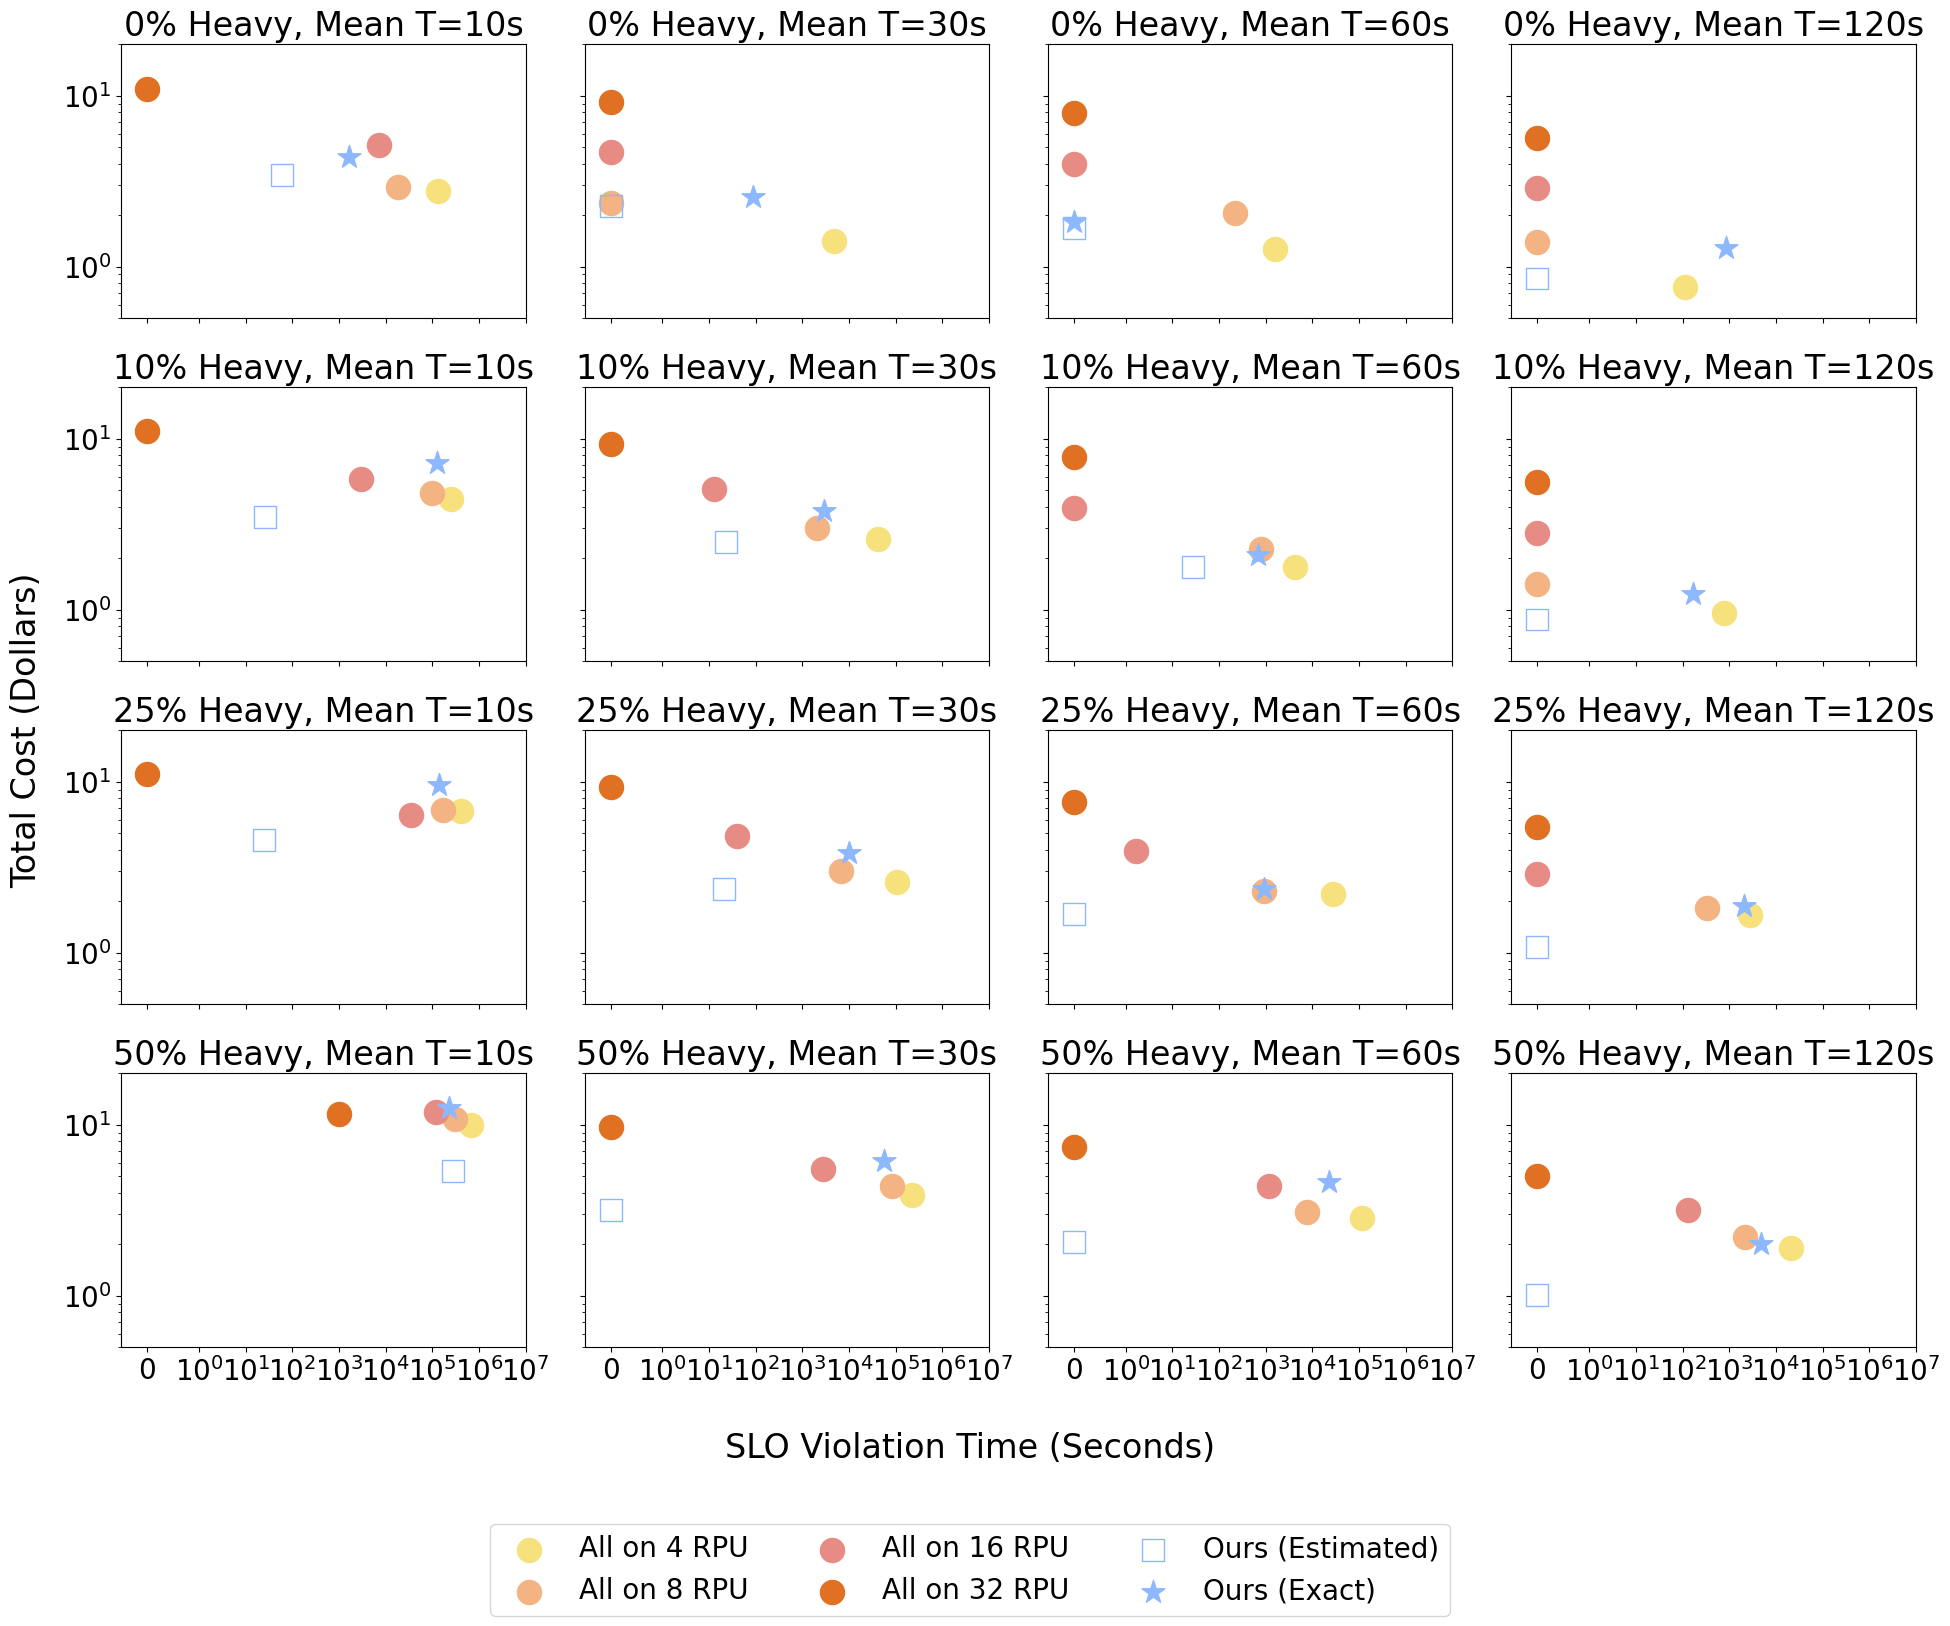

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(20, 15), sharex=True, sharey=True)


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]
        plot_one_panel(ax, pct_heavy, mean_interarrival, plot_time=True)
        

fig.supxlabel("SLO Violation Time (Seconds)")
fig.supylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.xscale("symlog", linthresh=1)
plt.xlim(left=-0.5, right=1e7)

plt.ylim(0.5, 20)


# Add a legend outside the plot, at the bottom center
handles, labels = axes[2,1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.savefig("chunk_grid_time.svg", bbox_inches='tight', dpi=300)
plt.show()

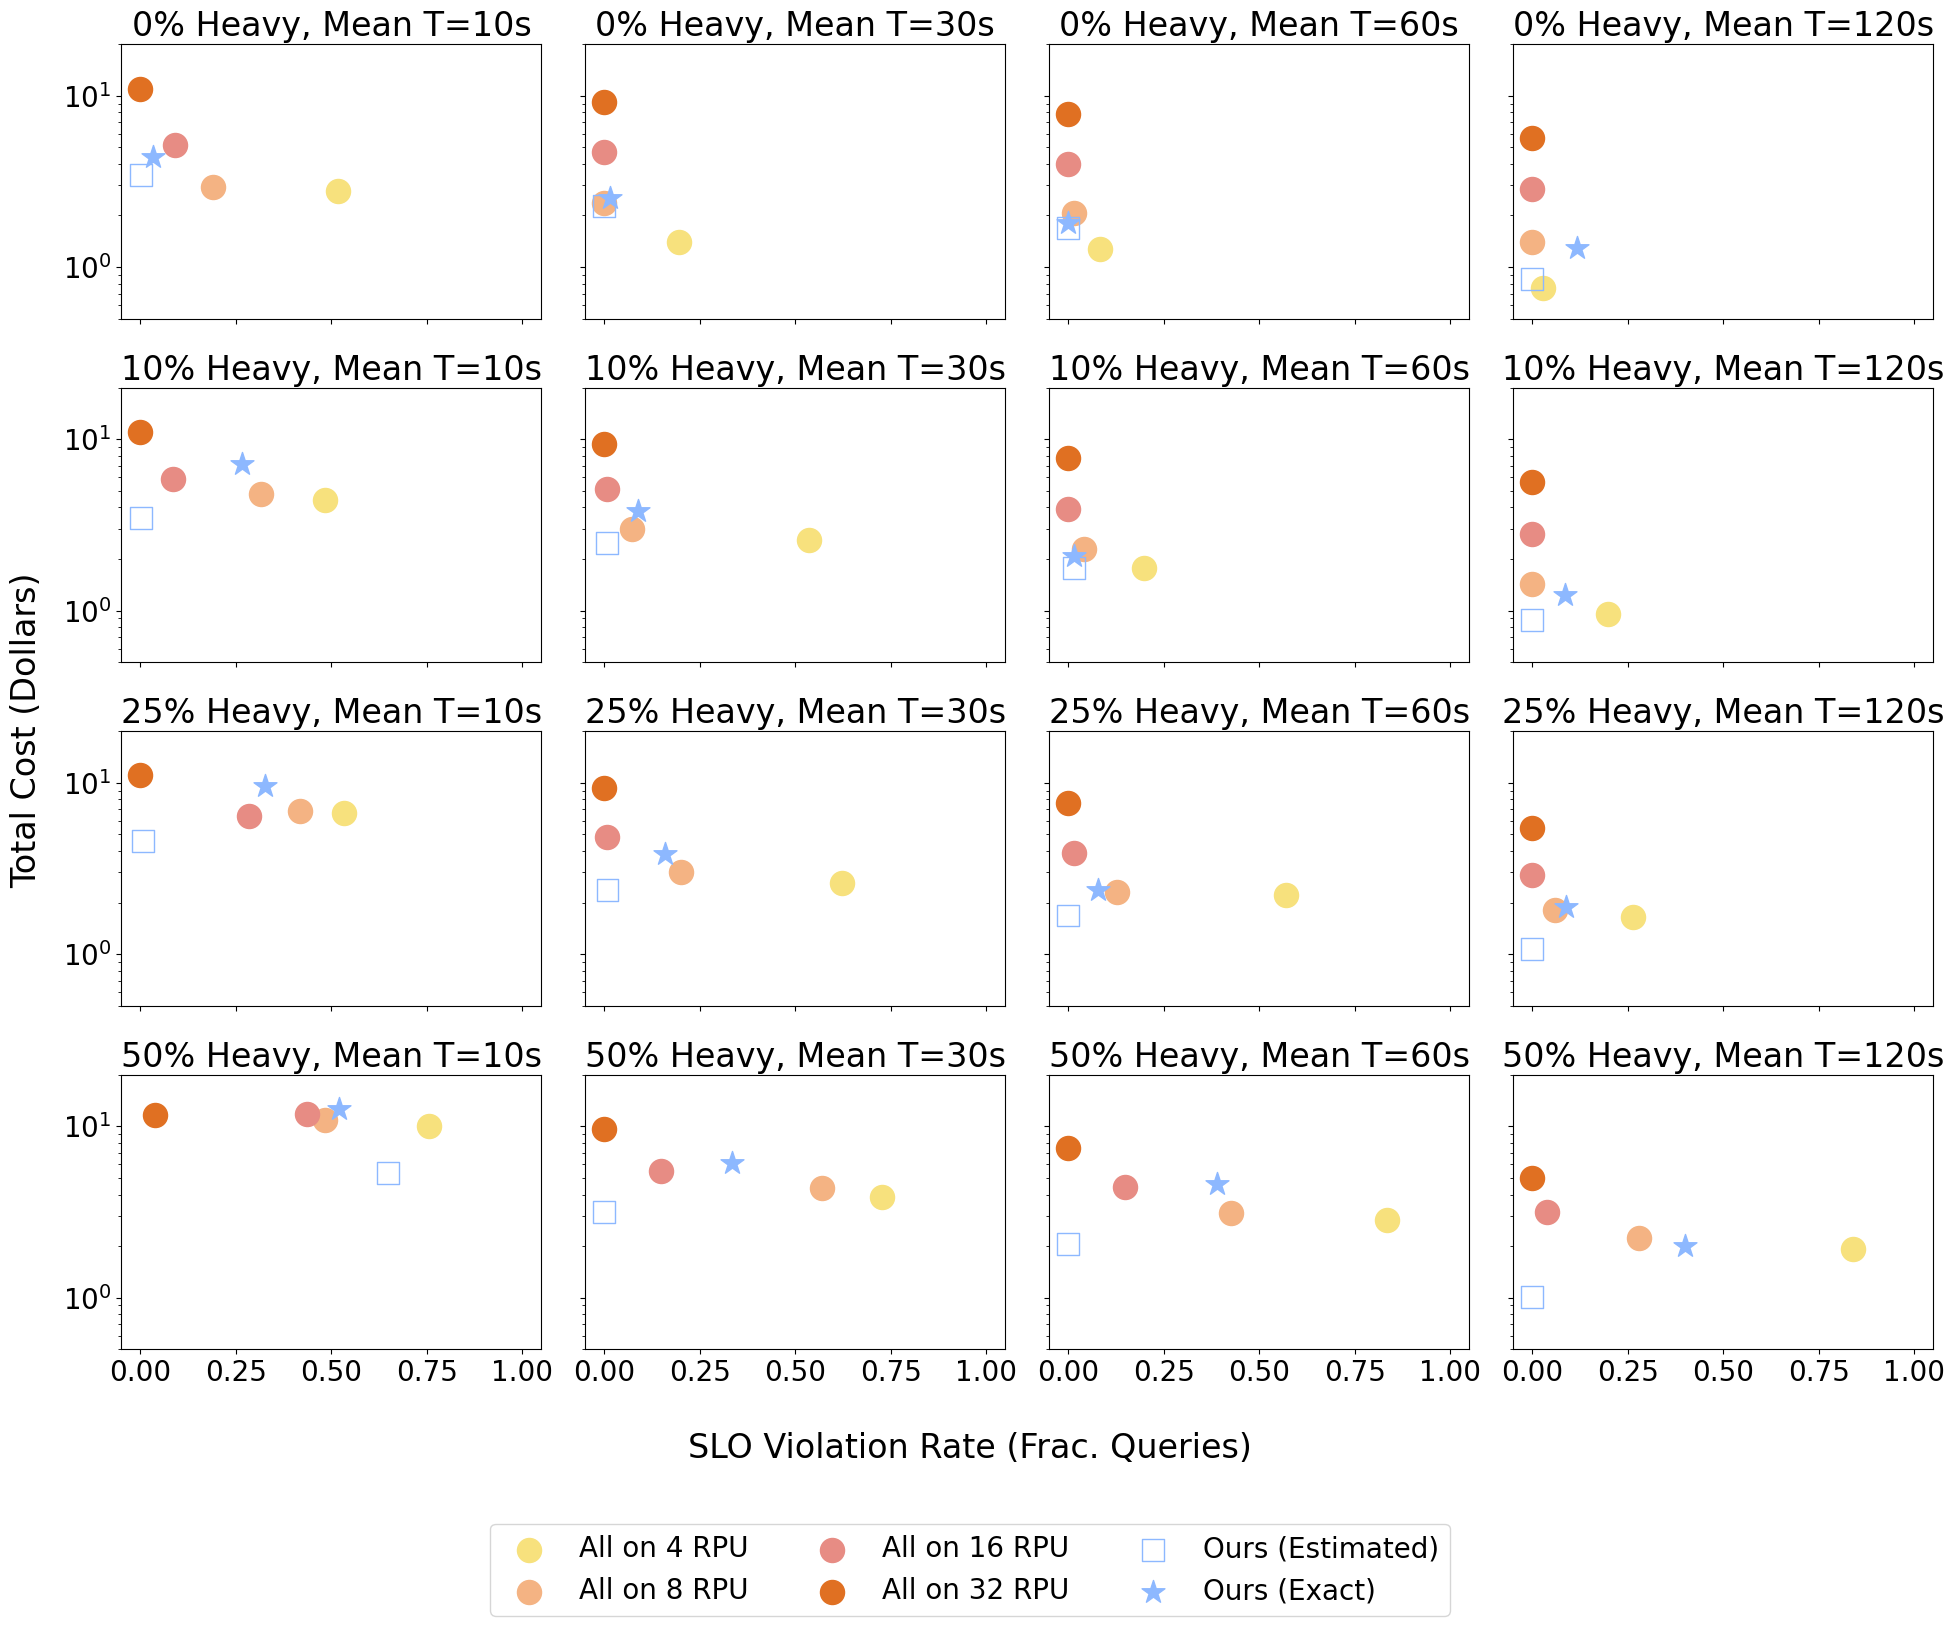

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(20, 15), sharex=True, sharey=True)


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]
        plot_one_panel(ax, pct_heavy, mean_interarrival)
        

fig.supxlabel("SLO Violation Rate (Frac. Queries)")
fig.supylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.xlim(left=-0.05, right=1.05)

plt.ylim(0.5, 20)


# Add a legend outside the plot, at the bottom center
handles, labels = axes[2,1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.savefig("chunk_grid_rate.svg", bbox_inches='tight', dpi=300)
plt.show()

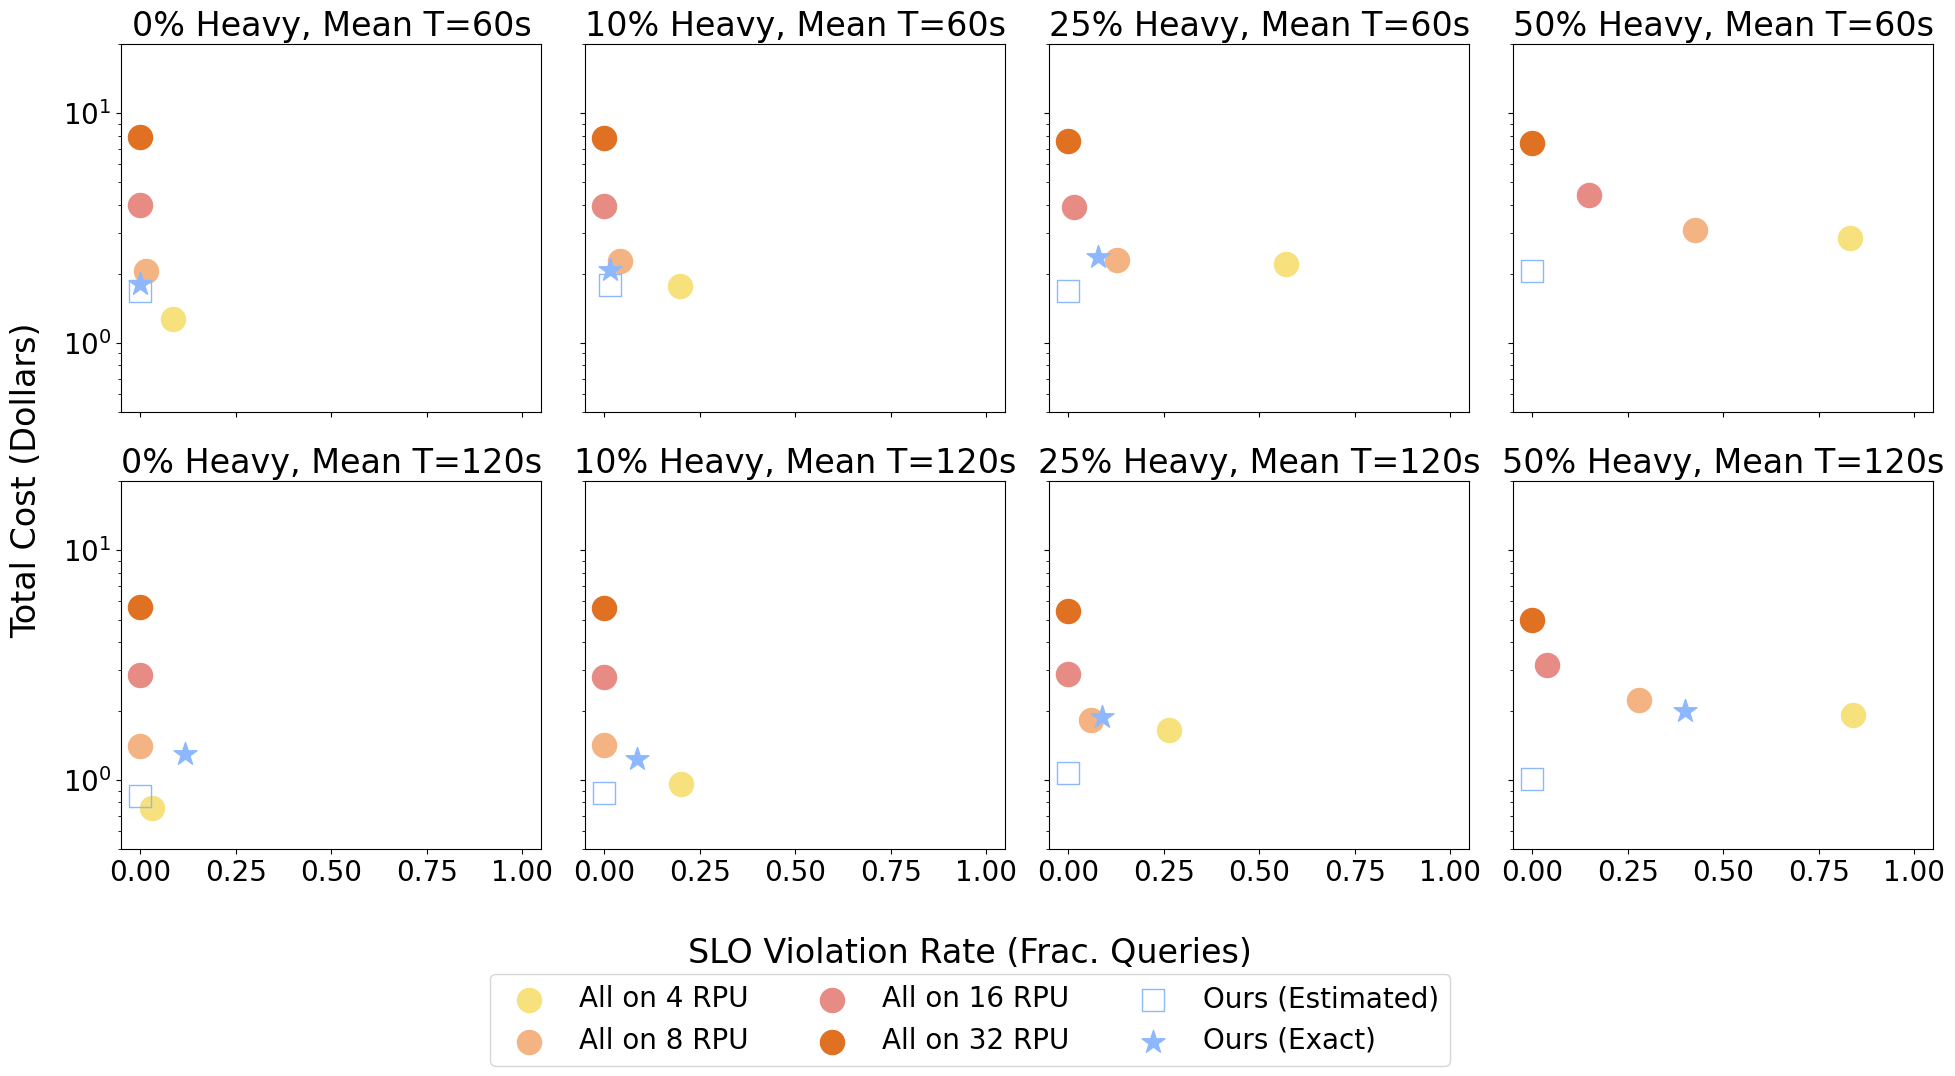

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options[-2:]):
        ax = axes[j, i]
        plot_one_panel(ax, pct_heavy, mean_interarrival)
        

fig.supxlabel("SLO Violation Rate (Frac. Queries)")
fig.supylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.xlim(left=-0.05, right=1.05)

plt.ylim(0.5, 20)


# Add a legend outside the plot, at the bottom center
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.savefig("chunk_grid_rate_partial.svg", bbox_inches='tight', dpi=300)
plt.show()

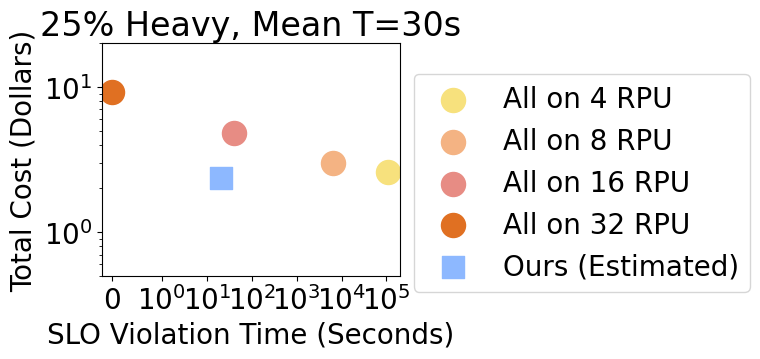

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True, sharey=True)



plot_one_panel(ax, 25, 30, plot_time=True)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.4))

ax.set_xlabel("SLO Violation Time (Seconds)")
ax.set_ylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.ylim(0.5, 20)
plt.xscale("symlog", linthresh=1)
# Show minor x ticks
plt.minorticks_on()
plt.xlim(left=-0.2, right=200000)
plt.tight_layout()
plt.savefig("chunk_grid_one_v2.svg", bbox_inches="tight")
plt.show()

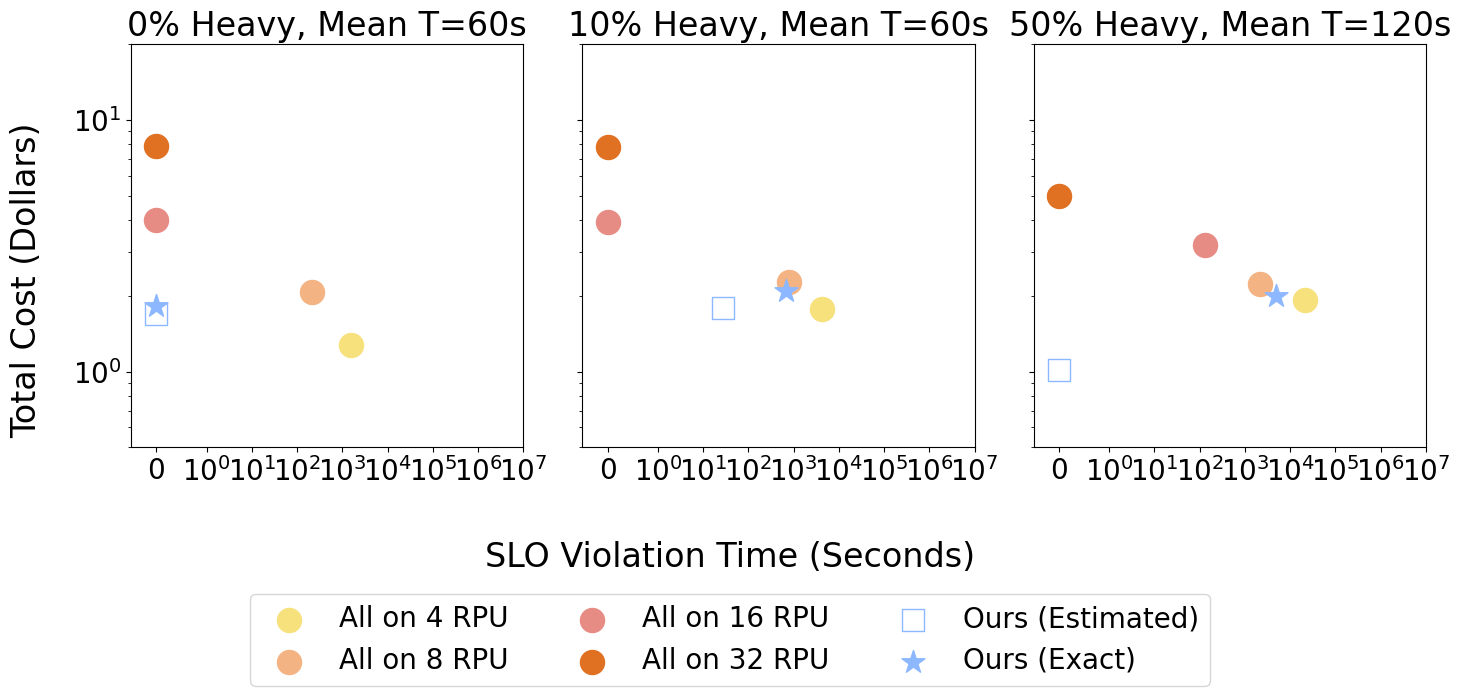

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True, sharex=True)

combos = [(0, 60), (10, 60), (50 ,120)]


for i, (pct_heavy, mean_interarrival) in enumerate(combos):
    ax = axes[i]
    plot_one_panel(ax, pct_heavy, mean_interarrival, plot_time=True)
        

fig.supxlabel("SLO Violation Time (Seconds)")
fig.supylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.xscale("symlog", linthresh=1)
plt.xlim(left=-0.5, right=1e7)

plt.ylim(0.5, 20)


# Add a legend outside the plot, at the bottom center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.2))

plt.tight_layout()
plt.savefig("chunk_grid_3_time.svg", bbox_inches='tight', dpi=300)
plt.show()

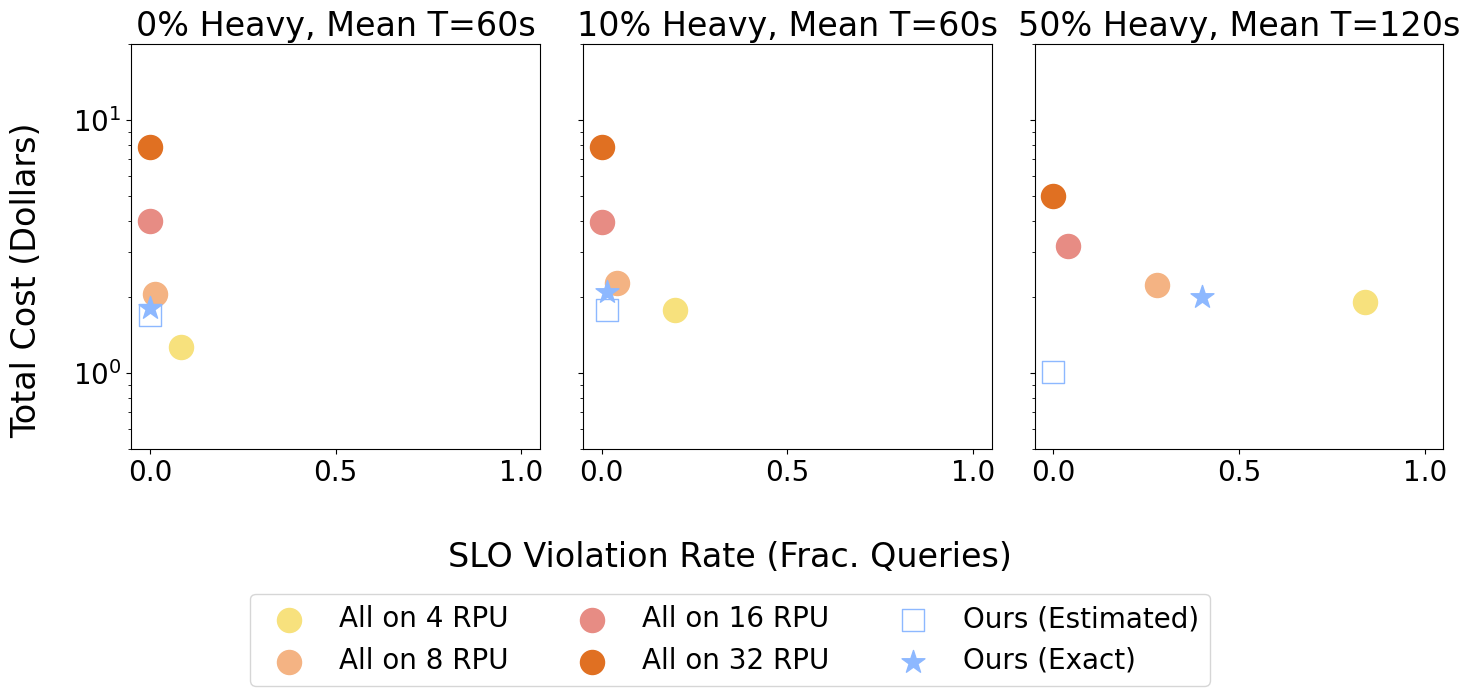

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True, sharex=True)

combos = [(0, 60), (10, 60), (50 ,120)]


for i, (pct_heavy, mean_interarrival) in enumerate(combos):
    ax = axes[i]
    plot_one_panel(ax, pct_heavy, mean_interarrival)
        

fig.supxlabel("SLO Violation Rate (Frac. Queries)")
fig.supylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.xlim(left=-0.05, right=1.05)


plt.ylim(0.5, 20)


# Add a legend outside the plot, at the bottom center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.2))

plt.tight_layout()
plt.savefig("chunk_grid_3_rate.svg", bbox_inches='tight', dpi=300)
plt.show()